# NLP Midterm Project
### AI Content Detection - Dataset 1 and Dataset 2

## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import spacy
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


nlp = spacy.load('en_core_web_sm')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Evaluation Function

In [31]:
results = {}

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, rep_name, dataset_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    results[(model_name, rep_name, dataset_name)] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f'{model_name} - {rep_name} - {dataset_name}')
    print(classification_report(y_te, y_pred, zero_division=0))
    cm = confusion_matrix(y_te, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f'{model_name} - {rep_name} - {dataset_name} Confusion Matrix')
    plt.show()
    return model

# PART 1: Dataset 1

## 3. Load Dataset

In [50]:
df1 = pd.read_csv('dataset/data1.csv')
df1 = df1.dropna(subset=['text', 'label'])
df1 = df1.reset_index(drop=True)
print(df1)

                                                    text  label
0      Phones\n\nModern humans today are always on th...      0
1      This essay will explain if drivers should or s...      0
2      Driving while the use of cellular devices\n\nT...      0
3      Phones & Driving\n\nDrivers should not be able...      0
4      Cell Phone Operation While Driving\n\nThe abil...      0
...                                                  ...    ...
86048  Today's society is ever-evolving and the role ...      1
86049  The ever-evolving world of technology has chan...      1
86050  Fostering a Rescue Dog: Gaining Unconditional ...      1
86051  The importance of a solid foundation in educat...      1
86052  Over the last decade, cities around the world ...      1

[86053 rows x 2 columns]


## 4. Case Folding

In [52]:
df1['step_casefold'] = df1['text'].apply(lambda t: str(t).lower())
df1[['text', 'step_casefold']].head(100)

,text,step_casefold
0,Phones\n\nModern humans today are always on th...,phones\n\nmodern humans today are always on th...
1,This essay will explain if drivers should or s...,this essay will explain if drivers should or s...
2,Driving while the use of cellular devices\n\nT...,driving while the use of cellular devices\n\nt...
3,Phones & Driving\n\nDrivers should not be able...,phones & driving\n\ndrivers should not be able...
4,Cell Phone Operation While Driving\n\nThe abil...,cell phone operation while driving\n\nthe abil...
...,...,...
95,Phones and Driving\n\nOver the last few years ...,phones and driving\n\nover the last few years ...
96,Today many people are on their phone & driving...,today many people are on their phone & driving...
97,Should Drivers use Cell phones while driving?\...,should drivers use cell phones while driving?\...
98,Phone & Driving\n\nIt has always been a big co...,phone & driving\n\nit has always been a big co...


## 5. Punctuation Removal

In [ ]:
def remove_punctuation(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    return text.translate(str.maketrans('', '', string.punctuation))

df1['step_punct'] = df1['step_casefold'].apply(remove_punctuation)
df1[['step_casefold', 'step_punct']].head(100)

,step_casefold,step_punct
0,def string_manipulation():\n # todo: implem...,def stringmanipulation\n todo implement st...
1,experts recommend focusing on health to improv...,experts recommend focusing on health to improv...
2,the development of finance technologies has ac...,the development of finance technologies has ac...
3,recent studies show that finance can have sign...,recent studies show that finance can have sign...
4,vector<int> arr; // graph traversal example\nf...,vectorint arr graph traversal example\nforint...
...,...,...
95,def sorting_algorithm():\n # todo: implemen...,def sortingalgorithm\n todo implement sort...
96,public class graph_traversal {\n public sta...,public class graphtraversal \n public stati...
97,recent studies show that education can have si...,recent studies show that education can have si...
98,the development of finance technologies has ac...,the development of finance technologies has ac...


## 6. Tokenization

In [ ]:
df1['step_tokens'] = df1['step_punct'].apply(word_tokenize)
df1[['step_punct', 'step_tokens']].head(100)

,step_punct,step_tokens
0,def stringmanipulation\n todo implement st...,"[def, stringmanipulation, todo, implement, str..."
1,experts recommend focusing on health to improv...,"[experts, recommend, focusing, on, health, to,..."
2,the development of finance technologies has ac...,"[the, development, of, finance, technologies, ..."
3,recent studies show that finance can have sign...,"[recent, studies, show, that, finance, can, ha..."
4,vectorint arr graph traversal example\nforint...,"[vectorint, arr, graph, traversal, example, fo..."
...,...,...
95,def sortingalgorithm\n todo implement sort...,"[def, sortingalgorithm, todo, implement, sorti..."
96,public class graphtraversal \n public stati...,"[public, class, graphtraversal, public, static..."
97,recent studies show that education can have si...,"[recent, studies, show, that, education, can, ..."
98,the development of finance technologies has ac...,"[the, development, of, finance, technologies, ..."


## 7. Stop Words Removal

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and t.isalpha()]

df1['step_stopwords'] = df1['step_tokens'].apply(remove_stopwords)
df1[['step_tokens', 'step_stopwords']].head(100)

,step_tokens,step_stopwords
0,"[def, stringmanipulation, todo, implement, str...","[def, stringmanipulation, todo, implement, str..."
1,"[experts, recommend, focusing, on, health, to,...","[experts, recommend, focusing, health, improve..."
2,"[the, development, of, finance, technologies, ...","[development, finance, technologies, accelerat..."
3,"[recent, studies, show, that, finance, can, ha...","[recent, studies, show, finance, significant, ..."
4,"[vectorint, arr, graph, traversal, example, fo...","[vectorint, arr, graph, traversal, example, fo..."
...,...,...
95,"[def, sortingalgorithm, todo, implement, sorti...","[def, sortingalgorithm, todo, implement, sorti..."
96,"[public, class, graphtraversal, public, static...","[public, class, graphtraversal, public, static..."
97,"[recent, studies, show, that, education, can, ...","[recent, studies, show, education, significant..."
98,"[the, development, of, finance, technologies, ...","[development, finance, technologies, accelerat..."


## 8. Synonym Substitution

In [ ]:


def substitute_synonyms(tokens):
    new_tokens = []
    for t in tokens:
        synsets = wordnet.synsets(t)
        replaced = t
        if synsets:
            lemma_names = synsets[0].lemma_names()
            candidate = lemma_names[0].replace('_', ' ') if lemma_names else t
            if candidate.isalpha():
                replaced = candidate.lower()
        new_tokens.append(replaced)
    return new_tokens

df1['step_synonyms'] = df1['step_stopwords'].apply(substitute_synonyms)
df1[['step_stopwords', 'step_synonyms']].head(100)

,step_stopwords,step_synonyms
0,"[def, stringmanipulation, todo, implement, str...","[def, stringmanipulation, todo, implement, str..."
1,"[experts, recommend, focusing, health, improve...","[expert, recommend, focus, health, better, ove..."
2,"[development, finance, technologies, accelerat...","[development, finance, technology, accelerate,..."
3,"[recent, studies, show, finance, significant, ...","[holocene, survey, show, finance, significant,..."
4,"[vectorint, arr, graph, traversal, example, fo...","[vectorint, arr, graph, traversal, example, fo..."
...,...,...
95,"[def, sortingalgorithm, todo, implement, sorti...","[def, sortingalgorithm, todo, implement, sort,..."
96,"[public, class, graphtraversal, public, static...","[populace, class, graphtraversal, populace, st..."
97,"[recent, studies, show, education, significant...","[holocene, survey, show, education, significan..."
98,"[development, finance, technologies, accelerat...","[development, finance, technology, accelerate,..."


## 9. Stemming

In [ ]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(t) for t in tokens]

df1['step_stemmed'] = df1['step_synonyms'].apply(apply_stemming)
df1[['step_synonyms', 'step_stemmed']].head(100)

,step_synonyms,step_stemmed
0,"[def, stringmanipulation, todo, implement, str...","[def, stringmanipul, todo, implement, string, ..."
1,"[expert, recommend, focus, health, better, ove...","[expert, recommend, focu, health, better, over..."
2,"[development, finance, technology, accelerate,...","[develop, financ, technolog, acceler, past, de..."
3,"[holocene, survey, show, finance, significant,...","[holocen, survey, show, financ, signific, impa..."
4,"[vectorint, arr, graph, traversal, example, fo...","[vectorint, arr, graph, travers, exampl, forin..."
...,...,...
95,"[def, sortingalgorithm, todo, implement, sort,...","[def, sortingalgorithm, todo, implement, sort,..."
96,"[populace, class, graphtraversal, populace, st...","[populac, class, graphtravers, populac, static..."
97,"[holocene, survey, show, education, significan...","[holocen, survey, show, educ, signific, impact..."
98,"[development, finance, technology, accelerate,...","[develop, financ, technolog, acceler, past, de..."


## 10. Lemmatization

In [ ]:

def apply_lemmatization(tokens):
    doc = nlp(' '.join(tokens))
    return [token.lemma_ for token in doc]

df1['clean_tokens'] = df1['step_stemmed'].apply(apply_lemmatization)
df1['clean_text'] = df1['clean_tokens'].apply(lambda tokens: ' '.join(tokens))
df1[['content', 'clean_text']].head(100)

,content,clean_text
0,def string_manipulation():\n # TODO: implem...,def stringmanipul todo implement string manipu...
1,Experts recommend focusing on health to improv...,expert recommend focu health well overal resul...
2,The development of finance technologies has ac...,develop financ technolog acceler past decad ex...
3,Recent studies show that finance can have sign...,holocen survey show financ signific impact soc...
4,vector<int> arr; // graph traversal example\nf...,vectorint arr graph traver exampl forint arrpu...
...,...,...
95,def sorting_algorithm():\n # TODO: implemen...,def sortingalgorithm todo implement sort algor...
96,public class graph_traversal {\n public sta...,populac class graphtraver populac static nothi...
97,Recent studies show that education can have si...,holocen survey show educ signific impact socie...
98,The development of finance technologies has ac...,develop financ technolog acceler past decad ex...


## 11. Train-Test Split

In [ ]:
X1 = df1['clean_text']
y1 = df1['label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

print(X_train1.shape, X_test1.shape)

(16000,) (4000,)


## 12. Vector Semantics - Bag of Words

In [14]:
bow_vectorizer1 = CountVectorizer()
X_train_bow1 = bow_vectorizer1.fit_transform(X_train1)
X_test_bow1 = bow_vectorizer1.transform(X_test1)

print(X_train_bow1.shape, X_test_bow1.shape)

(16000, 65) (4000, 65)


## 13. Vector Semantics - TF-IDF

In [ ]:
tfidf_vectorizer1 = TfidfVectorizer()
X_train_tfidf1 = tfidf_vectorizer1.fit_transform(X_train1)
X_test_tfidf1 = tfidf_vectorizer1.transform(X_test1)

print(X_train_tfidf1.shape, X_test_tfidf1.shape)

(16000, 65) (4000, 65)


## 14. Naive Bayes

Naive Bayes - BoW - Dataset 1
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      2001
       human       1.00      1.00      1.00      1999

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



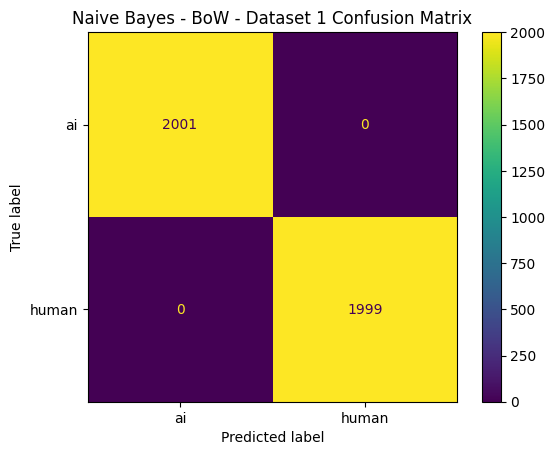

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[8003.,7997.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U5](2,)","['ai','human']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 65)","[[3530.,8003., 802.,...,3735., 660.,3572.], [3530., 0., 824.,...,3542., 700.,3605.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 65)","[[ -3.76, -2.94, -5.24,..., -3.71, -5.44, -3.75], [ -3.7 ,-11.87, -5.15,..., -3.7 , -5.32, -3.68]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,65


In [ ]:
nb_bow1 = MultinomialNB()
evaluate_model(nb_bow1, X_train_bow1, X_test_bow1, y_train1, y_test1, 'Naive Bayes', 'BoW', 'Dataset 1')

Naive Bayes - TF-IDF - Dataset 1
              precision    recall  f1-score   support

          ai       0.93      1.00      0.96      2001
       human       1.00      0.92      0.96      1999

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



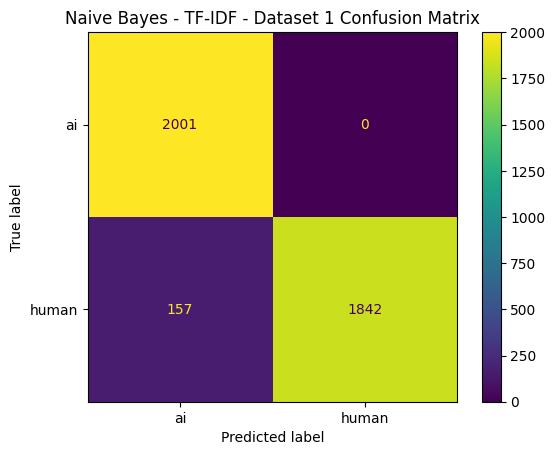

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[8003.,7997.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U5](2,)","['ai','human']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 65)","[[ 370.58,1118.23, 304.96,..., 388.81, 261.73, 367.53], [ 369.3 , 0. , 316.86,..., 369.01, 282.96, 372.66]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 65)","[[ -4.19, -3.09, -4.38,..., -4.14, -4.54, -4.2 ], [ -4.15,-10.07, -4.31,..., -4.15, -4.42, -4.14]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,65


In [ ]:
nb_tfidf1 = MultinomialNB()
evaluate_model(nb_tfidf1, X_train_tfidf1, X_test_tfidf1, y_train1, y_test1, 'Naive Bayes', 'TF-IDF', 'Dataset 1')

## 15. Logistic Regression

Logistic Regression - BoW - Dataset 1
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      2001
       human       1.00      1.00      1.00      1999

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



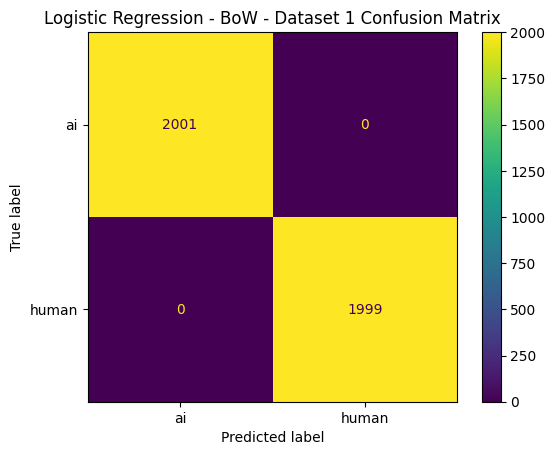

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
lr_bow1 = LogisticRegression(max_iter=1000)
evaluate_model(lr_bow1, X_train_bow1, X_test_bow1, y_train1, y_test1, 'Logistic Regression', 'BoW', 'Dataset 1')

Logistic Regression - TF-IDF - Dataset 1
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      2001
       human       1.00      1.00      1.00      1999

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



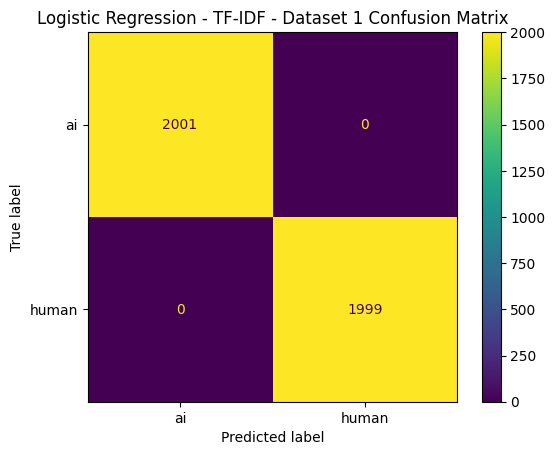

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [19]:
lr_tfidf1 = LogisticRegression(max_iter=1000)
evaluate_model(lr_tfidf1, X_train_tfidf1, X_test_tfidf1, y_train1, y_test1, 'Logistic Regression', 'TF-IDF', 'Dataset 1')

## 16. Support Vector Machine

SVM - BoW - Dataset 1
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      2001
       human       1.00      1.00      1.00      1999

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



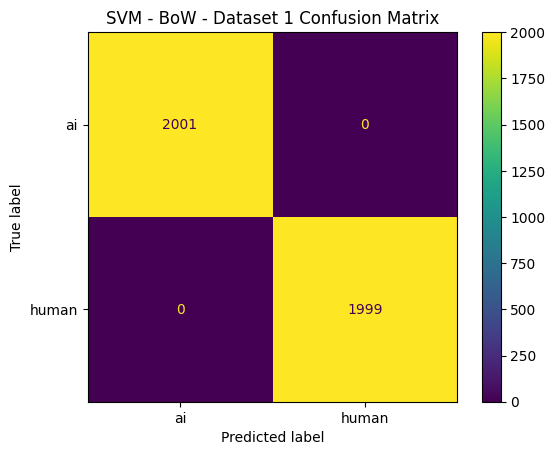

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [ ]:
svm_bow1 = LinearSVC()
evaluate_model(svm_bow1, X_train_bow1, X_test_bow1, y_train1, y_test1, 'SVM', 'BoW', 'Dataset 1')

SVM - TF-IDF - Dataset 1
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      2001
       human       1.00      1.00      1.00      1999

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



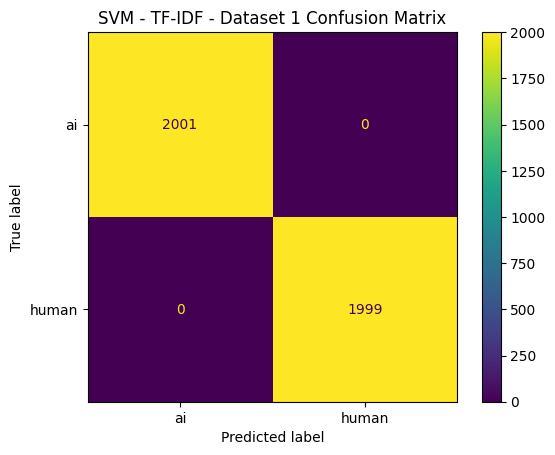

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [ ]:
svm_tfidf1 = LinearSVC()
evaluate_model(svm_tfidf1, X_train_tfidf1, X_test_tfidf1, y_train1, y_test1, 'SVM', 'TF-IDF', 'Dataset 1')

# PART 2: Dataset 2

## 17. Load Dataset

In [ ]:
df2 = pd.read_csv('dataset/data2.csv')
df2 = df2.dropna(subset=['content', 'label'])
df2 = df2.reset_index(drop=True)
print(df2)

                                                    text  label
0      Phones\n\nModern humans today are always on th...      0
1      This essay will explain if drivers should or s...      0
2      Driving while the use of cellular devices\n\nT...      0
3      Phones & Driving\n\nDrivers should not be able...      0
4      Cell Phone Operation While Driving\n\nThe abil...      0
...                                                  ...    ...
86048  Today's society is ever-evolving and the role ...      1
86049  The ever-evolving world of technology has chan...      1
86050  Fostering a Rescue Dog: Gaining Unconditional ...      1
86051  The importance of a solid foundation in educat...      1
86052  Over the last decade, cities around the world ...      1

[86053 rows x 2 columns]


## 18. Case Folding

In [ ]:
df2['step_casefold'] = df2['content'].apply(lambda t: str(t).lower())
df2[['content', 'step_casefold']].head(100)

,text,step_casefold
0,Phones\n\nModern humans today are always on th...,phones\n\nmodern humans today are always on th...
1,This essay will explain if drivers should or s...,this essay will explain if drivers should or s...
2,Driving while the use of cellular devices\n\nT...,driving while the use of cellular devices\n\nt...
3,Phones & Driving\n\nDrivers should not be able...,phones & driving\n\ndrivers should not be able...
4,Cell Phone Operation While Driving\n\nThe abil...,cell phone operation while driving\n\nthe abil...
...,...,...
95,Phones and Driving\n\nOver the last few years ...,phones and driving\n\nover the last few years ...
96,Today many people are on their phone & driving...,today many people are on their phone & driving...
97,Should Drivers use Cell phones while driving?\...,should drivers use cell phones while driving?\...
98,Phone & Driving\n\nIt has always been a big co...,phone & driving\n\nit has always been a big co...


## 19. Punctuation Removal

In [24]:
def remove_punctuation(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    return text.translate(str.maketrans('', '', string.punctuation))

df2['step_punct'] = df2['step_casefold'].apply(remove_punctuation)
df2[['step_casefold', 'step_punct']].head(100)

,step_casefold,step_punct
0,phones\n\nmodern humans today are always on th...,phones\n\nmodern humans today are always on th...
1,this essay will explain if drivers should or s...,this essay will explain if drivers should or s...
2,driving while the use of cellular devices\n\nt...,driving while the use of cellular devices\n\nt...
3,phones & driving\n\ndrivers should not be able...,phones driving\n\ndrivers should not be able ...
4,cell phone operation while driving\n\nthe abil...,cell phone operation while driving\n\nthe abil...
...,...,...
95,phones and driving\n\nover the last few years ...,phones and driving\n\nover the last few years ...
96,today many people are on their phone & driving...,today many people are on their phone driving ...
97,should drivers use cell phones while driving?\...,should drivers use cell phones while driving\n...
98,phone & driving\n\nit has always been a big co...,phone driving\n\nit has always been a big con...


## 20. Tokenization

In [25]:
df2['step_tokens'] = df2['step_punct'].apply(word_tokenize)
df2[['step_punct', 'step_tokens']].head(100)

,step_punct,step_tokens
0,phones\n\nmodern humans today are always on th...,"[phones, modern, humans, today, are, always, o..."
1,this essay will explain if drivers should or s...,"[this, essay, will, explain, if, drivers, shou..."
2,driving while the use of cellular devices\n\nt...,"[driving, while, the, use, of, cellular, devic..."
3,phones driving\n\ndrivers should not be able ...,"[phones, driving, drivers, should, not, be, ab..."
4,cell phone operation while driving\n\nthe abil...,"[cell, phone, operation, while, driving, the, ..."
...,...,...
95,phones and driving\n\nover the last few years ...,"[phones, and, driving, over, the, last, few, y..."
96,today many people are on their phone driving ...,"[today, many, people, are, on, their, phone, d..."
97,should drivers use cell phones while driving\n...,"[should, drivers, use, cell, phones, while, dr..."
98,phone driving\n\nit has always been a big con...,"[phone, driving, it, has, always, been, a, big..."


## 21. Stop Words Removal

In [26]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and t.isalpha()]

df2['step_stopwords'] = df2['step_tokens'].apply(remove_stopwords)
df2[['step_tokens', 'step_stopwords']].head(100)

,step_tokens,step_stopwords
0,"[phones, modern, humans, today, are, always, o...","[phones, modern, humans, today, always, phone,..."
1,"[this, essay, will, explain, if, drivers, shou...","[essay, explain, drivers, able, use, electroni..."
2,"[driving, while, the, use, of, cellular, devic...","[driving, use, cellular, devices, today, socie..."
3,"[phones, driving, drivers, should, not, be, ab...","[phones, driving, drivers, able, use, phones, ..."
4,"[cell, phone, operation, while, driving, the, ...","[cell, phone, operation, driving, ability, sta..."
...,...,...
95,"[phones, and, driving, over, the, last, few, y...","[phones, driving, last, years, many, records, ..."
96,"[today, many, people, are, on, their, phone, d...","[today, many, people, phone, driving, time, ce..."
97,"[should, drivers, use, cell, phones, while, dr...","[drivers, use, cell, phones, driving, would, w..."
98,"[phone, driving, it, has, always, been, a, big...","[phone, driving, always, big, concern, phone, ..."


## 22. Synonym Substitution

In [27]:
def substitute_synonyms(tokens):
    new_tokens = []
    for t in tokens:
        synsets = wordnet.synsets(t)
        replaced = t
        if synsets:
            lemma_names = synsets[0].lemma_names()
            candidate = lemma_names[0].replace('_', ' ') if lemma_names else t
            if candidate.isalpha():
                replaced = candidate.lower()
        new_tokens.append(replaced)
    return new_tokens

df2['step_synonyms'] = df2['step_stopwords'].apply(substitute_synonyms)
df2[['step_stopwords', 'step_synonyms']].head(100)

,step_stopwords,step_synonyms
0,"[phones, modern, humans, today, always, phone,...","[telephone, modern, world, today, always, tele..."
1,"[essay, explain, drivers, able, use, electroni...","[essay, explain, driver, able, use, electronic..."
2,"[driving, use, cellular, devices, today, socie...","[drive, use, cellular, devices, today, society..."
3,"[phones, driving, drivers, able, use, phones, ...","[telephone, drive, driver, able, use, telephon..."
4,"[cell, phone, operation, driving, ability, sta...","[cell, telephone, operation, drive, ability, s..."
...,...,...
95,"[phones, driving, last, years, many, records, ...","[telephone, drive, last, years, many, record, ..."
96,"[today, many, people, phone, driving, time, ce...","[today, many, people, telephone, drive, time, ..."
97,"[drivers, use, cell, phones, driving, would, w...","[driver, use, cell, telephone, drive, would, w..."
98,"[phone, driving, always, big, concern, phone, ...","[telephone, drive, always, large, concern, tel..."


## 23. Stemming

In [48]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(t) for t in tokens]

df2['step_stemmed'] = df2['step_synonyms'].apply(apply_stemming)
df2[['step_synonyms', 'step_stemmed']].head(100)

,step_synonyms,step_stemmed
0,"[def, stringmanipulation, todo, implement, str...","[def, stringmanipul, todo, implement, string, ..."
1,"[expert, recommend, focus, health, better, ove...","[expert, recommend, focu, health, better, over..."
2,"[development, finance, technology, accelerate,...","[develop, financ, technolog, acceler, past, de..."
3,"[holocene, survey, show, finance, significant,...","[holocen, survey, show, financ, signific, impa..."
4,"[vectorint, arr, graph, traversal, example, fo...","[vectorint, arr, graph, travers, exampl, forin..."
...,...,...
95,"[def, sortingalgorithm, todo, implement, sort,...","[def, sortingalgorithm, todo, implement, sort,..."
96,"[populace, class, graphtraversal, populace, st...","[populac, class, graphtravers, populac, static..."
97,"[holocene, survey, show, education, significan...","[holocen, survey, show, educ, signific, impact..."
98,"[development, finance, technology, accelerate,...","[develop, financ, technolog, acceler, past, de..."


## 24. Lemmatization

In [ ]:


def apply_lemmatization(tokens):
    doc = nlp(' '.join(tokens))
    return [token.lemma_ for token in doc]

df2['clean_tokens'] = df2['step_stemmed'].apply(apply_lemmatization)
df2['clean_text'] = df2['clean_tokens'].apply(lambda tokens: ' '.join(tokens))
df2[['content', 'clean_text']].head(50)

## 25. Train-Test Split

In [ ]:
X2 = df2['clean_text']
y2 = df2['label']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(X_train2.shape, X_test2.shape)

## 26. Vector Semantics - Bag of Words

In [ ]:
bow_vectorizer2 = CountVectorizer()
X_train_bow2 = bow_vectorizer2.fit_transform(X_train2)
X_test_bow2 = bow_vectorizer2.transform(X_test2)

print(X_train_bow2.shape, X_test_bow2.shape)

## 27. Vector Semantics - TF-IDF

In [ ]:
tfidf_vectorizer2 = TfidfVectorizer()
X_train_tfidf2 = tfidf_vectorizer2.fit_transform(X_train2)
X_test_tfidf2 = tfidf_vectorizer2.transform(X_test2)

print(X_train_tfidf2.shape, X_test_tfidf2.shape)

## 28. Naive Bayes

In [ ]:
nb_bow2 = MultinomialNB()
evaluate_model(nb_bow2, X_train_bow2, X_test_bow2, y_train2, y_test2, 'Naive Bayes', 'BoW', 'Dataset 2')

In [ ]:
nb_tfidf2 = MultinomialNB()
evaluate_model(nb_tfidf2, X_train_tfidf2, X_test_tfidf2, y_train2, y_test2, 'Naive Bayes', 'TF-IDF', 'Dataset 2')

## 29. Logistic Regression

In [ ]:
lr_bow2 = LogisticRegression(max_iter=1000)
evaluate_model(lr_bow2, X_train_bow2, X_test_bow2, y_train2, y_test2, 'Logistic Regression', 'BoW', 'Dataset 2')

In [ ]:
lr_tfidf2 = LogisticRegression(max_iter=1000)
evaluate_model(lr_tfidf2, X_train_tfidf2, X_test_tfidf2, y_train2, y_test2, 'Logistic Regression', 'TF-IDF', 'Dataset 2')

## 30. Support Vector Machine

In [ ]:
svm_bow2 = LinearSVC()
evaluate_model(svm_bow2, X_train_bow2, X_test_bow2, y_train2, y_test2, 'SVM', 'BoW', 'Dataset 2')

In [ ]:
svm_tfidf2 = LinearSVC()
evaluate_model(svm_tfidf2, X_train_tfidf2, X_test_tfidf2, y_train2, y_test2, 'SVM', 'TF-IDF', 'Dataset 2')

## 31. Combined Results Summary Table

In [ ]:
results_df = pd.DataFrame(results).T
results_df.index.names = ['Algorithm', 'Representation', 'Dataset']
results_df

## 32. Accuracy Pivot Table (Dataset 1 vs Dataset 2)

In [ ]:
accuracy_table = results_df['accuracy'].unstack('Dataset')
accuracy_table